# Task 3: Forest Cover Type Classification

In [ ]:
import pandas as pd
import numpy as np

covtype_file_path = "covtype.csv"
df = pd.read_csv(covtype_file_path)
print(df.shape)
print(df.head())

(581012, 55)
   Elevation  Aspect  Slope  Horizontal_Distance_To_Hydrology  \
0       2596      51      3                               258   
1       2590      56      2                               212   
2       2804     139      9                               268   
3       2785     155     18                               242   
4       2595      45      2                               153   

   Vertical_Distance_To_Hydrology  Horizontal_Distance_To_Roadways  \
0                               0                              510   
1                              -6                              390   
2                              65                             3180   
3                             118                             3090   
4                              -1                              391   

   Hillshade_9am  Hillshade_Noon  Hillshade_3pm  \
0            221             232            148   
1            220             235            151   
2            234      

In [17]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance


RND = 42
print(df['Cover_Type'].value_counts().sort_index())

# continuous features 
feature_names = list(df.columns)
continuous = feature_names[:10]           # Elevation..Horizontal_Distance_To_Fire_Points
wilderness = feature_names[10:14]         # Wilderness_Area1..4
soil = feature_names[14:54]               # Soil_Type1..Soil_Type40
target_name = 'Cover_Type'


Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


In [ ]:
# 2. downcast
df[continuous] = df[continuous].astype(np.float32)     # continuous -> float32
df[wilderness+soil] = df[wilderness+soil].astype(np.uint8)  # binaries -> uint8
df[target_name] = df[target_name].astype(np.uint8)

df[target_name] = df[target_name] - 1  

X = df.drop(columns=[target_name])
y = df[target_name]

In [ ]:
# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RND, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (464809, 54) Test shape: (116203, 54)


RF accuracy: 0.9533316695782381
RF balanced accuracy: 0.9052626798932254
              precision    recall  f1-score   support

           0     0.9632    0.9415    0.9522     42368
           1     0.9484    0.9728    0.9604     56661
           2     0.9393    0.9601    0.9496      7151
           3     0.9162    0.8561    0.8851       549
           4     0.9543    0.7699    0.8522      1899
           5     0.9296    0.8903    0.9095      3473
           6     0.9729    0.9461    0.9593      4102

    accuracy                         0.9533    116203
   macro avg     0.9463    0.9053    0.9241    116203
weighted avg     0.9535    0.9533    0.9531    116203



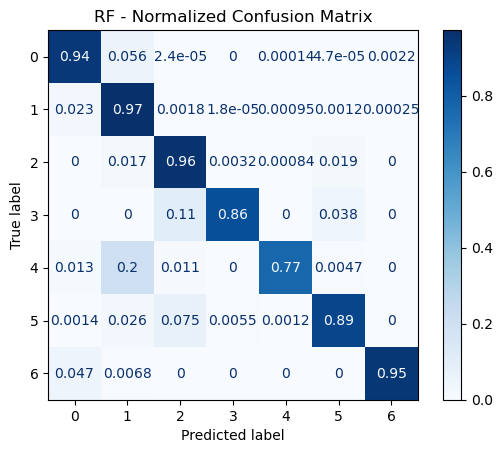

In [22]:
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RND)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
print("RF accuracy:", accuracy_score(y_test, y_pred_rf))
print("RF balanced accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))

# normalized confusion matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, normalize='true', cmap='Blues')
plt.title("RF - Normalized Confusion Matrix")
plt.show()


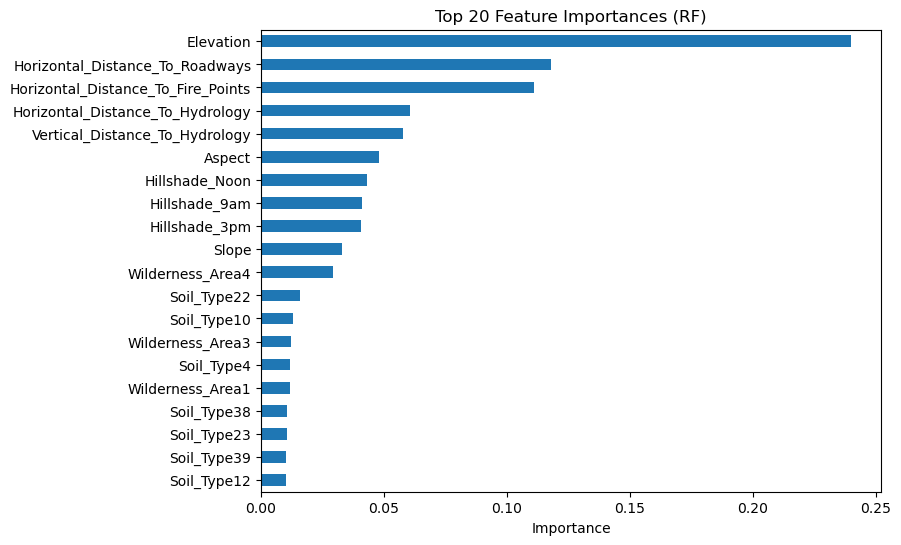

In [23]:
fi = pd.Series(rf.feature_importances_, index=X.columns)
top20 = fi.sort_values(ascending=False).head(20)
plt.figure(figsize=(8,6))
top20[::-1].plot(kind='barh')
plt.title("Top 20 Feature Importances (RF)")
plt.xlabel("Importance")
plt.show()


In [ ]:
X_train_np = X_train.values
X_test_np  = X_test.values

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    n_jobs=-1,
    random_state=RND
)

xgb.fit(X_train_np, y_train.values, eval_set=[(X_test_np, y_test.values)],
         early_stopping_rounds=10, verbose=50)

y_pred_xgb = xgb.predict(X_test_np)
print("XGB accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, digits=4))


[0]	validation_0-mlogloss:1.75746
[50]	validation_0-mlogloss:0.51873
[100]	validation_0-mlogloss:0.44800
[150]	validation_0-mlogloss:0.41464
[199]	validation_0-mlogloss:0.38551
XGB accuracy: 0.8419059748887723
              precision    recall  f1-score   support

           0     0.8364    0.8113    0.8237     42368
           1     0.8402    0.8801    0.8597     56661
           2     0.8475    0.8852    0.8659      7151
           3     0.8597    0.8597    0.8597       549
           4     0.8916    0.4286    0.5789      1899
           5     0.8050    0.6919    0.7442      3473
           6     0.9302    0.8701    0.8991      4102

    accuracy                         0.8419    116203
   macro avg     0.8587    0.7753    0.8045    116203
weighted avg     0.8423    0.8419    0.8403    116203



In [ ]:
MAX_SAMPLE = 20_000
sample_size = min(MAX_SAMPLE, X_train.shape[0])
X_sample, _, y_sample, _ = train_test_split(
    X_train, y_train, train_size=sample_size, stratify=y_train, random_state=RND
)
print("Sample for tuning:", X_sample.shape)

# RandomizedSearchCV  RandomForest 
rf_param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(n_jobs=-1, random_state=RND),
    rf_param_dist,
    n_iter=10,             
    cv=2,                 
    scoring='balanced_accuracy',
    verbose=2,
    n_jobs=-1,
    random_state=RND
)
rs_rf.fit(X_sample, y_sample)
print("Best RF params:", rs_rf.best_params_)
print("Best RF score (cv):", rs_rf.best_score_)

# RandomizedSearchCV  XGBoost 
xgb_param_dist = {
    'n_estimators': [50, 100, 200],      
    'max_depth': [3, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

rs_xgb = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1, random_state=RND),
    xgb_param_dist,
    n_iter=12,           
    cv=2,                 
    scoring='balanced_accuracy',
    verbose=2,
    n_jobs=1,             
    random_state=RND
)
rs_xgb.fit(X_sample.values, y_sample.values)
print("Best XGB params:", rs_xgb.best_params_)
print("Best XGB score (cv):", rs_xgb.best_score_)

best_rf = rs_rf.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best_rf = best_rf.predict(X_test)
print("Final RF balanced acc:", balanced_accuracy_score(y_test, y_pred_best_rf))

best_xgb = rs_xgb.best_estimator_
best_xgb.fit(X_train.values, y_train.values)
y_pred_best_xgb = best_xgb.predict(X_test.values)
print("Final XGB balanced acc:", balanced_accuracy_score(y_test, y_pred_best_xgb))


Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best RF score (cv): nan
Fitting 2 folds for each of 12 candidates, totalling 24 fits
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   2.3s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=1.0; total time=   2.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=0.8; total time=   4.6s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=3, n_estimators=200, subsample=0.8; total time=   5.0s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   2.7s
[CV] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, n_estimators=100, subsample=0.8; total time=   2.1s
[CV] END colsample_bytree=1.0, learning_rate=0.1, max_depth=6, n_estimators=50, subsample=1.0

              precision    recall  f1-score   support

           0     0.9639    0.9376    0.9506     42368
           1     0.9451    0.9733    0.9590     56661
           2     0.9350    0.9587    0.9467      7151
           3     0.9119    0.8488    0.8792       549
           4     0.9529    0.7567    0.8436      1899
           5     0.9297    0.8877    0.9082      3473
           6     0.9730    0.9417    0.9571      4102

    accuracy                         0.9516    116203
   macro avg     0.9445    0.9007    0.9206    116203
weighted avg     0.9518    0.9516    0.9513    116203

Final XGB balanced acc: 0.6235051359882515
              precision    recall  f1-score   support

           0     0.7541    0.7377    0.7458     42368
           1     0.7746    0.8291    0.8009     56661
           2     0.7383    0.8423    0.7869      7151
           3     0.8330    0.7541    0.7916       549
           4     0.8109    0.1964    0.3162      1899
           5     0.6441    0.3487  

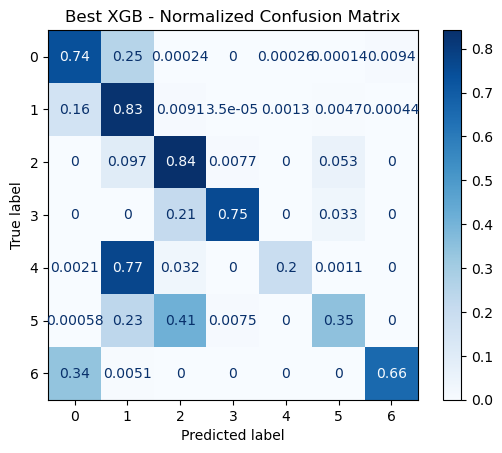

In [31]:
print(classification_report(y_test, y_pred_best_rf, digits=4))

best_xgb = rs_xgb.best_estimator_
best_xgb.fit(X_train.values, y_train.values)
y_pred_best_xgb = best_xgb.predict(X_test.values)
print("Final XGB balanced acc:", balanced_accuracy_score(y_test, y_pred_best_xgb))
print(classification_report(y_test, y_pred_best_xgb, digits=4))

# Confusion matrix for the winner (example: XGB)
ConfusionMatrixDisplay.from_estimator(best_xgb, X_test.values, y_test.values, normalize='true', cmap='Blues')
plt.title("Best XGB - Normalized Confusion Matrix")
plt.show()


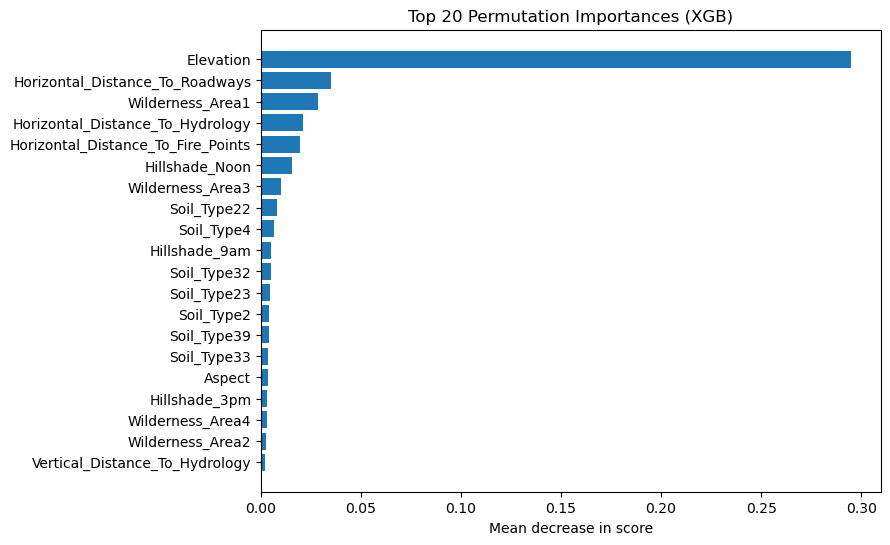

In [29]:
res = permutation_importance(best_xgb, X_test.values, y_test.values, n_repeats=8, random_state=RND, n_jobs=-1)
imp_means = res.importances_mean
imp_idx = np.argsort(imp_means)[::-1][:20]
plt.figure(figsize=(8,6))
plt.barh(np.array(X.columns)[imp_idx][::-1], imp_means[imp_idx][::-1])
plt.title("Top 20 Permutation Importances (XGB)")
plt.xlabel("Mean decrease in score")
plt.show()

In [ ]:
joblib.dump(best_rf, "best_rf_covtype.joblib")
joblib.dump(best_xgb, "best_xgb_covtype.joblib")

# classification_report 
with open("report_best_xgb.txt","w") as f:
    f.write(classification_report(y_test, y_pred_best_xgb, digits=4))
